In [2]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
from sklearn import metrics
import numpy as np

colors = plt.cm.tab10.colors  # or use 'Set3', 'Accent', etc., for more variety
# If there are more than 10 bars, repeat colors or use a larger colormap
colors = list(colors) * (10 // len(colors) + 1)

plt.style.use('ggplot')

In [3]:
def interpolate(p1_fpr, p1_tpr, p2_fpr, p2_tpr, x):
    """
    Linear interpolation of TPR at FPR = x between points (p1_fpr, p1_tpr) and (p2_fpr, p2_tpr).
    """
    slope = (p2_tpr - p1_tpr) / (p2_fpr - p1_fpr)
    return p1_tpr + slope * (x - p1_fpr)


def tpr_for_fpr(fprsample, fpr_arr, tpr_arr):
    """
    Implements Algorithm 3's helper that finds / interpolates TPR at a specific FPR.
    Assumes fpr_arr is sorted ascending and has the same length as tpr_arr.
    """
    # Locate the rightmost point whose FPR ≤ fprsample
    i = np.searchsorted(fpr_arr, fprsample, side="right") - 1
    # Edge cases: before first point or exactly at end
    if i < 0:                     # fprsample < smallest FPR in curve
        return tpr_arr[0]
    if fpr_arr[i] == fprsample or i == len(fpr_arr) - 1:
        return tpr_arr[i]
    # Otherwise interpolate between point i and i+1
    return interpolate(fpr_arr[i], tpr_arr[i],
                       fpr_arr[i + 1], tpr_arr[i + 1],
                       fprsample)

def vertical_avg_roc(roc_data):
    '''
    ROC curve averaging function.
    Takes a list of ROC data (each element is a tuple of fpr, tpr, thresholds)
    all the fpr values are concatenated and sorted, then the fpr of each curve is sampled
    at these points, and then averaged
    :param roc_data: list of tuples (fpr, tpr, thresholds)
    :return: tuple (fpr, tpr) of the averaged ROC curve 
    '''
    fprs = []
    tprs = []
    for fpr, tpr, _ in roc_data:
        fprs.append(fpr)
        tprs.append(tpr)
    fprs = np.concatenate(fprs)

    # make sure fprs ends with 1 and starts with 0
    if fprs[0] != 0:
        fprs = np.insert(fprs, 0, 0)
    if fprs[-1] != 1:
        fprs = np.append(fprs, 1)
    
    fprs = np.sort(np.unique(fprs))
    tprs=np.zeros(shape=(len(roc_data),len(fprs)))

    for i, fpr in enumerate(fprs):
        for curve_idx,(fpr_arr, tpr_arr, _) in enumerate(roc_data):
            tprs[curve_idx, i] = tpr_for_fpr(fpr, fpr_arr, tpr_arr)
    tpr = np.mean(tprs, axis=0)
    return fprs, tpr




In [4]:
def compute_threshold_slope(n_epileptic, n_healthy, posterior_threshold=0.6):
    """
    Compute the slope of the ROC threshold line for a given posterior probability.

    Parameters:
    - n_epileptic: int, number of epileptic cases in dataset
    - n_healthy: int, number of healthy subjects in dataset
    - posterior_threshold: float, required posterior probability after positive test (default=0.6)

    Returns:
    - slope: float, multiplier for FPR to get required sensitivity (ROC space)
    """
    # Prior probabilities from data
    p_epileptic = n_epileptic / (n_epileptic + n_healthy)
    p_healthy = 1 - p_epileptic

    # Calculate slope in ROC space
    slope = (posterior_threshold * p_healthy) / (p_epileptic * (1 - posterior_threshold))

    return slope

In [5]:
feat_types=['spectral','cwt','dwt','mst','sst','cc','plv','gcc','gplv','utm']
featnames={'spectral':'S',
           'cwt':'CWT',
           'dwt':'DWT',
           'mst':'mST',
              'sst':'sST',
              'cc':'CC',
                'plv':'PLV',
                'gcc':'GCC',
                'gplv':'GPLV',
                'utm':'UTM'}


In [6]:
DATADIR_W_IEDS = '/space/gzanardini/tuh/tuh_singleset_final/'
DATADIR_NOIED = '/space/gzanardini/tuh/tuh_singleset_noied_final/'

#data is in the format: predictions_Laplacian_utm_60s_mean_run_0_seed_4086 for the whole data
# predictions_{montage}_{featuretype}_{length}s_{combiner}_run_#_seed_{seed}.csv the columns are y
# and for the epoched data
# predictions_{montage}_{featuretype}_{length}s_{combiner}_run_#_seed_{seed}_subjects.csv

def get_predictions_files(datadir, montage, featuretype, length, combiner, seeds, epochs=False):
    if not epochs:
        files = [file for file in os.listdir(datadir) if file.startswith(f'predictions_{montage}_{featuretype}_{length}s_{combiner}_run_') and file.endswith('.csv')]
        files = [file for file in files if any(f'_seed_{seed}' in file for seed in seeds)]

    else:
        files = [file for file in os.listdir(datadir) if file.endswith('_subjects.csv')]
        files = [file for file in files if file.startswith(f'{featuretype}_{montage}_{length}s_{combiner}_run_') and file.endswith('.csv')]
        files = [file for file in files if any(f'_seed_{seed}' in file for seed in seeds)]
        #match the seeds in the file names 
        files = [file for file in files if any( file.split('_')[-2] == str(seed) for seed in seeds)]

    return files

# Whole Data

<>:44: SyntaxWarning: invalid escape sequence '\g'
<>:44: SyntaxWarning: invalid escape sequence '\g'
/tmp/ipykernel_41207/3348410796.py:44: SyntaxWarning: invalid escape sequence '\g'
  plt.fill_between([0, 1], [0, slope],[1, slope], color='green', alpha=0.1, label=f'P(Epilepsy|y=1)$\geq$0.6')


spectral Pooled AUC: 0.81
cwt Pooled AUC: 0.82
dwt Pooled AUC: 0.77
mst Pooled AUC: 0.75
sst Pooled AUC: 0.80
cc Pooled AUC: 0.79
plv Pooled AUC: 0.79
gcc Pooled AUC: 0.70
gplv Pooled AUC: 0.53
utm Pooled AUC: 0.88


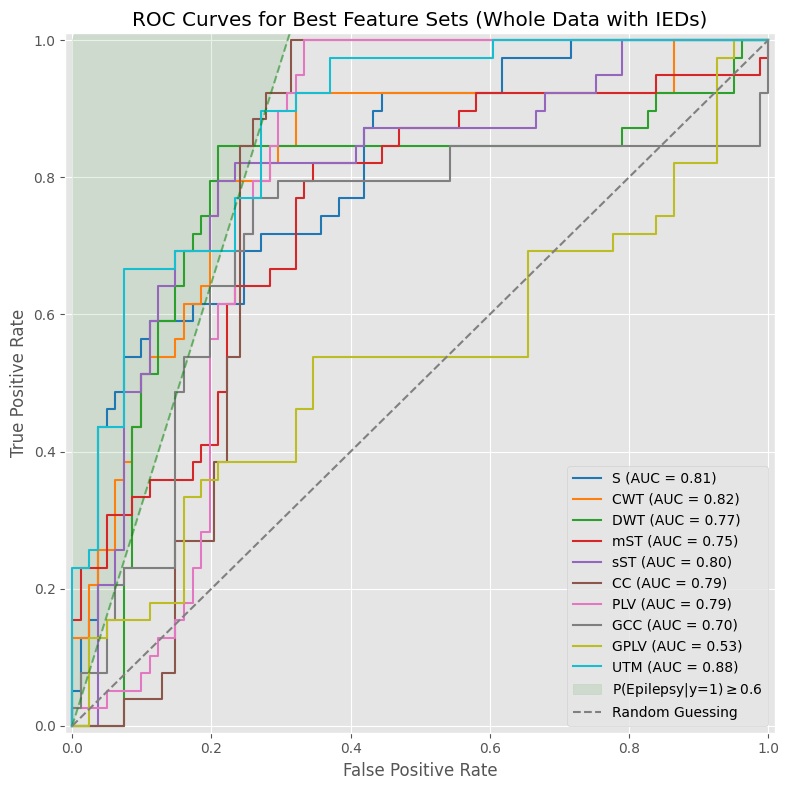

In [7]:
best_runs_whole_with_ied = {
    'spectral': ('CAR',1,'skew',('1732','1899','2989')),
    'cwt': ('BipolarDB',60,'std',('2733','971','126')),
    'dwt': ('Cz',10,'skew',('371','4303','3635')),
    'mst': ('BipolarDB',10,'skew',('3979','1027','1143')),
    'sst': ('Laplacian',20,'skew',('3706','2580','3988')),
    'cc': ('Cz',10,'skew',('4374','4025','2768')),
    'plv': ('Laplacian',2,'std',('4867','2825','2116')),
    'gcc': ('CAR',1,'std',('509','2256','4676')),
    'gplv': ('BipolarDB',1,'mean',('1502','638','1620')),
    'utm': ('Laplacian',60,'mean',('4086','812','3952'))
}

plt.figure(figsize=(8,8))

for feature_type in feat_types:
    montage, length, combiner, seeds = best_runs_whole_with_ied[feature_type]

    predictions_files = get_predictions_files(DATADIR_W_IEDS, montage, feature_type, length, combiner, seeds, epochs=False)

    roc_data = []
    preds=pd.DataFrame(columns=['y_tests','y_scores'])
    for file in predictions_files:
        df = pd.read_csv(os.path.join(DATADIR_W_IEDS, file))
        y_true = df['y_tests'].values
        y_pred = df['y_scores'].values

        fpr, tpr, thresholds = metrics.roc_curve(y_true, y_pred)
        roc_data.append((fpr, tpr, thresholds))
        preds = pd.concat([preds, df[['y_tests', 'y_scores']]],axis=0, ignore_index=True)
    fpr, tpr = vertical_avg_roc(roc_data)
    # pooled ROC curve
    y_true = np.array(preds['y_tests'].values).astype(np.float64)
    y_pred = np.array(preds['y_scores'].values).astype(np.float64)
    fpr_pooled, tpr_pooled, _ = metrics.roc_curve(y_true=y_true, y_score=y_pred)
    auc_pooled = metrics.auc(fpr_pooled, tpr_pooled)
    plt.step(fpr_pooled, tpr_pooled, label=f'{featnames[feature_type]} (AUC = {auc_pooled:.2f})', color=colors[feat_types.index(feature_type)], linestyle='solid')
    print(f'{feature_type} Pooled AUC: {auc_pooled:.2f}')

slope=compute_threshold_slope(13,28,0.6)
# plot a line with this slope, limit the y axis to [0, 1]
plt.plot([0, 1], [0, slope], '--', color='green', alpha=0.5)
#fill above the line
plt.fill_between([0, 1], [0, slope],[1, slope], color='green', alpha=0.1, label=f'P(Epilepsy|y=1)$\geq$0.6')
plt.title('ROC Curves for Best Feature Sets (Whole Data with IEDs)')



plt.plot([0, 1], [0, 1], '--', label='Random Guessing', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.xlim([-0.01, 1.01])
plt.ylim([-0.01, 1.01])
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.savefig('tuh_ss_whole_roc.pdf', bbox_inches='tight')
plt.show()



<>:42: SyntaxWarning: invalid escape sequence '\g'
<>:42: SyntaxWarning: invalid escape sequence '\g'
/tmp/ipykernel_41207/754291181.py:42: SyntaxWarning: invalid escape sequence '\g'
  plt.fill_between([0, 1], [0, slope],[1, slope], color='green', alpha=0.1, label=f'P(Epilepsy|y=1)$\geq$0.6')


spectral Pooled AUC: 0.85, average AUC: 0.87
cwt Pooled AUC: 0.81, average AUC: 0.83
dwt Pooled AUC: 0.75, average AUC: 0.78
mst Pooled AUC: 0.69, average AUC: 0.72
sst Pooled AUC: 0.85, average AUC: 0.86
cc Pooled AUC: 0.83, average AUC: 0.85
plv Pooled AUC: 0.83, average AUC: 0.85
gcc Pooled AUC: 0.72, average AUC: 0.75
gplv Pooled AUC: 0.60, average AUC: 0.66
utm Pooled AUC: 0.82, average AUC: 0.84


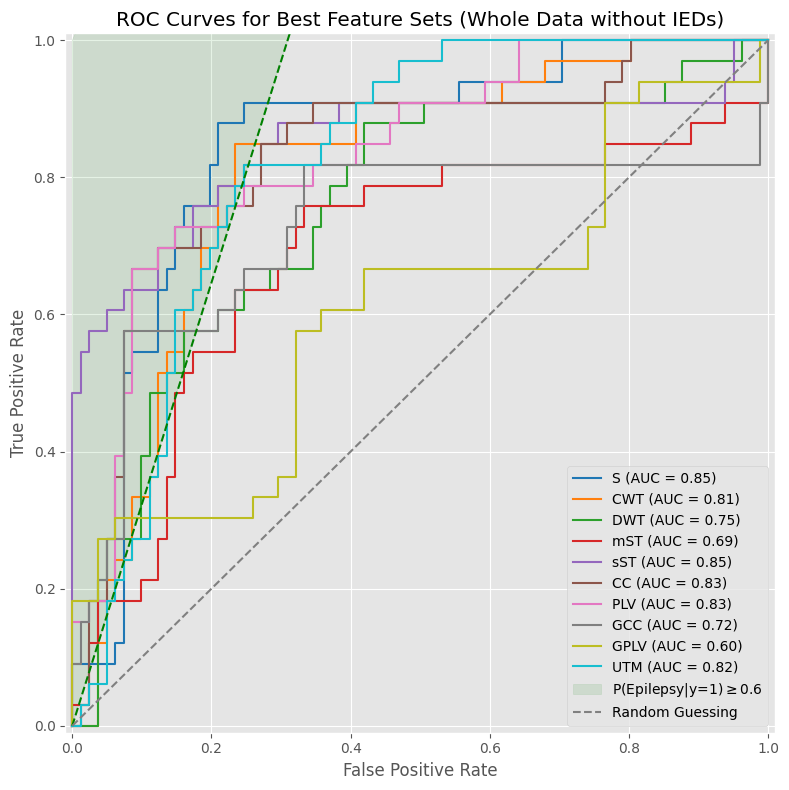

In [8]:
best_runs_whole_without_ied = {
    'spectral': ('CAR',20,'std',('2971','401','2177')),
    'cwt': ('BipolarDB',60,'std',('3795','3470','2758')),
    'dwt': ('Laplacian',20,'std',('3882','1911','193')),
    'mst': ('BipolarDB',10,'skew',('3877','4073','1759')),
    'sst': ('CAR',20,'mean',('4699','1715','1681')),
    'cc': ('Cz',60,'median',('2246','692','3825')),
    'plv': ('BipolarDB',5,'median',('2563','241','4962')),  
    'gcc': ('Laplacian',5,'mean',('980','2719','2899')),
    'gplv': ('BipolarDB',10,'median',('4559','3141','4971')),
    'utm': ('CAR',1,'median',('2078','2559','4735'))
}

plt.figure(figsize=(8,8))
for feature_type in feat_types:
    montage, length, combiner, seeds = best_runs_whole_without_ied[feature_type]

    predictions_files = get_predictions_files(DATADIR_NOIED, montage, feature_type, length, combiner, seeds, epochs=False)

    roc_data = []
    preds=pd.DataFrame(columns=['y_tests','y_scores'])
    for file in predictions_files:
        df = pd.read_csv(os.path.join(DATADIR_NOIED, file))
        y_true = df['y_tests'].values
        y_pred = df['y_scores'].values

        fpr, tpr, thresholds = metrics.roc_curve(y_true, y_pred)
        roc_data.append((fpr, tpr, thresholds))
        preds = pd.concat([preds, df[['y_tests', 'y_scores']]],axis=0, ignore_index=True)
    fpr, tpr = vertical_avg_roc(roc_data)
    # pooled ROC curve
    y_true = np.array(preds['y_tests'].values).astype(np.float64)
    y_pred = np.array(preds['y_scores'].values).astype(np.float64)
    fpr_pooled, tpr_pooled, _ = metrics.roc_curve(y_true=y_true, y_score=y_pred)
    auc_pooled = metrics.auc(fpr_pooled, tpr_pooled)
    plt.plot(fpr_pooled, tpr_pooled, label=f'{featnames[feature_type]} (AUC = {auc_pooled:.2f})', color=colors[feat_types.index(feature_type)], linestyle='solid')
    print(f'{feature_type} Pooled AUC: {auc_pooled:.2f}, average AUC: {metrics.auc(fpr, tpr):.2f}')

slope=compute_threshold_slope(13,28,0.6)
# plot a line with this slope, limit the y axis to [0, 1]
plt.plot([0, 1], [0, slope], '--', color='green')
plt.fill_between([0, 1], [0, slope],[1, slope], color='green', alpha=0.1, label=f'P(Epilepsy|y=1)$\geq$0.6')

plt.title('ROC Curves for Best Feature Sets (Whole Data with IEDs)')

plt.title('ROC Curves for Best Feature Sets (Whole Data without IEDs)')
plt.plot([0, 1], [0, 1], '--', label='Random Guessing', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.xlim([-0.01, 1.01])
plt.ylim([-0.01, 1.01])
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.savefig('tuh_ss_whole_roc_noied.pdf', bbox_inches='tight')
plt.show()

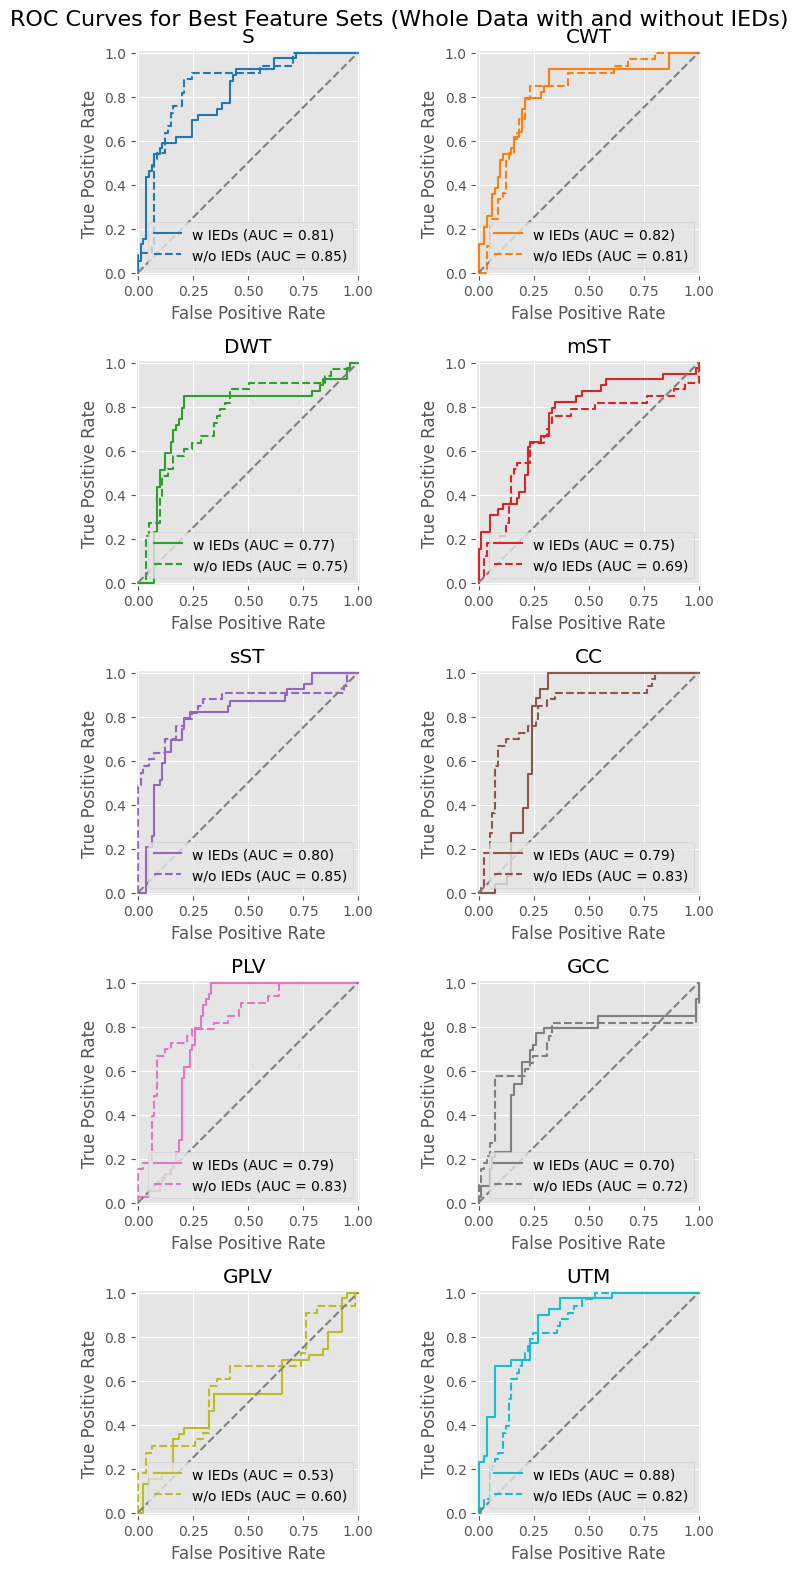

In [9]:
# 5x2 subplots with the ROC curves for each feature type comparing the whole data with and without IEDs
fig, axs = plt.subplots(5, 2, figsize=(7, 16))
axs = axs.flatten()

for i, feature_type in enumerate(feat_types):
    montage, length, combiner, seeds = best_runs_whole_with_ied[feature_type]
    predictions_files = get_predictions_files(DATADIR_W_IEDS, montage, feature_type, length, combiner, seeds, epochs=False)

    roc_data = []
    preds=pd.DataFrame(columns=['y_tests','y_scores'])
    for file in predictions_files:
        df = pd.read_csv(os.path.join(DATADIR_W_IEDS, file))
        y_true = df['y_tests'].values
        y_pred = df['y_scores'].values

        fpr, tpr, thresholds = metrics.roc_curve(y_true, y_pred)
        roc_data.append((fpr, tpr, thresholds))
        preds = pd.concat([preds, df[['y_tests', 'y_scores']]],axis=0, ignore_index=True)
    fpr_w_ied, tpr_w_ied = vertical_avg_roc(roc_data)
    # pooled ROC curve
    y_true = np.array(preds['y_tests'].values).astype(np.float64)
    y_pred = np.array(preds['y_scores'].values).astype(np.float64)
    fpr_pooled_w_ied, tpr_pooled_w_ied, _ = metrics.roc_curve(y_true=y_true, y_score=y_pred)
    auc_pooled_w_ied = metrics.auc(fpr_pooled_w_ied, tpr_pooled_w_ied)

    montage_noied, length_noied, combiner_noied, seeds_noied = best_runs_whole_without_ied[feature_type]
    predictions_files_noied = get_predictions_files(DATADIR_NOIED, montage_noied, feature_type, length_noied, combiner_noied, seeds_noied, epochs=False)

    roc_data_noied = []
    preds_noied=pd.DataFrame(columns=['y_tests','y_scores'])
    for file in predictions_files_noied:
        df = pd.read_csv(os.path.join(DATADIR_NOIED, file))
        y_true_noied = df['y_tests'].values
        y_pred_noied = df['y_scores'].values

        fpr_noied, tpr_noied, thresholds_noied = metrics.roc_curve(y_true_noied, y_pred_noied)
        roc_data_noied.append((fpr_noied, tpr_noied, thresholds_noied))
        preds_noied    = pd.concat([preds_noied, df[['y_tests', 'y_scores']]],axis=0, ignore_index=True)   
    fpr_noied, tpr_noied = vertical_avg_roc(roc_data_noied)
    # pooled ROC curve
    y_true_noied = np.array(preds_noied['y_tests'].values).astype(np.float64)
    y_pred_noied = np.array(preds_noied['y_scores'].values).astype(np.float64)
    fpr_pooled_noied, tpr_pooled_noied, _ = metrics.roc_curve(y_true=y_true_noied, y_score=y_pred_noied)
    auc_pooled_noied = metrics.auc(fpr_pooled_noied, tpr_pooled_noied)
    axs[i].plot(fpr_pooled_w_ied, tpr_pooled_w_ied, label=f'w IEDs (AUC = {auc_pooled_w_ied:.2f})', color=colors[i], linestyle='solid')

    axs[i].plot(fpr_pooled_noied, tpr_pooled_noied, label=f'w/o IEDs (AUC = {auc_pooled_noied:.2f})', color=colors[i], linestyle='dashed')
    axs[i].set_title(f'{featnames[feature_type]}')
    axs[i].plot([0, 1], [0, 1], '--', label='', color='gray')
    axs[i].set_xlabel('False Positive Rate')
    axs[i].set_ylabel('True Positive Rate')
    axs[i].set_xlim([-0.01, 1.01])
    axs[i].set_ylim([-0.01, 1.01])
    axs[i].legend(loc='lower right')
    axs[i].grid(True)
    axs[i].set_aspect('equal')
plt.suptitle('ROC Curves for Best Feature Sets (Whole Data with and without IEDs)', fontsize=16)
plt.tight_layout()
plt.show()


# Epoch Data

['spectral_Cz_2s_median_run_2_seed_1720_subjects.csv', 'spectral_Cz_2s_median_run_0_seed_2623_subjects.csv', 'spectral_Cz_2s_median_run_1_seed_2281_subjects.csv']
spectral Pooled AUC: 0.66
['cwt_Laplacian_5s_kurt_run_0_seed_1128_subjects.csv', 'cwt_Laplacian_5s_kurt_run_2_seed_1573_subjects.csv', 'cwt_Laplacian_5s_kurt_run_1_seed_925_subjects.csv']
cwt Pooled AUC: 0.70
['dwt_Laplacian_1s_std_run_1_seed_300_subjects.csv', 'dwt_Laplacian_1s_std_run_2_seed_2467_subjects.csv', 'dwt_Laplacian_1s_std_run_0_seed_1701_subjects.csv']
dwt Pooled AUC: 0.71
['mst_CAR_10s_skew_run_0_seed_1758_subjects.csv', 'mst_CAR_10s_skew_run_2_seed_4884_subjects.csv', 'mst_CAR_10s_skew_run_1_seed_4276_subjects.csv']
mst Pooled AUC: 0.66
['sst_CAR_1s_kurt_run_0_seed_1686_subjects.csv', 'sst_CAR_1s_kurt_run_1_seed_3199_subjects.csv', 'sst_CAR_1s_kurt_run_2_seed_3203_subjects.csv']
sst Pooled AUC: 0.70
['cc_Cz_10s_skew_run_2_seed_2544_subjects.csv', 'cc_Cz_10s_skew_run_1_seed_897_subjects.csv', 'cc_Cz_10s_skew_run

['utm_Laplacian_1s_median_run_1_seed_1078_subjects.csv', 'utm_Laplacian_1s_median_run_2_seed_4663_subjects.csv', 'utm_Laplacian_1s_median_run_0_seed_220_subjects.csv']
utm Pooled AUC: 0.76


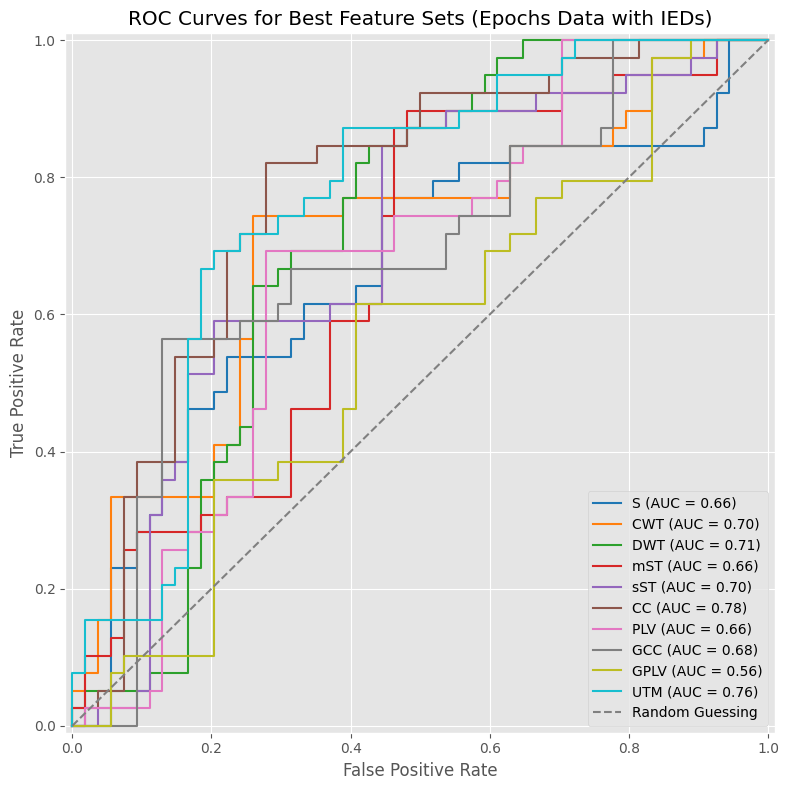

In [10]:
best_runs_epochs_with_ieds = {
    'spectral': ('Cz',2,'median',('2623','2281','1720')),
    'cwt': ('Laplacian',5,'kurt',('925','1128','1573')),
    'dwt': ('Laplacian',1,'std',('2467','300','1701')),
    'mst': ('CAR',10,'skew',('4884','1758','4276')),
    'sst': ('CAR',1,'kurt',('3199','3203','1686')),
    'cc': ('Cz',10,'skew',('1789','897','2544')),
    'plv': ('BipolarDB',10,'kurt',('856','781','192')),
    'gcc': ('Cz',1,'kurt',('4311','4033','3756')),
    'gplv': ('BipolarDB',1,'kurt',('4887','3812','3811')),
    'utm': ('Laplacian',1,'median',('1078','4663','220'))
}



# now repeat the same for the epochs data
plt.figure(figsize=(8,8))
for feature_type in feat_types:
    montage, length, combiner, seeds = best_runs_epochs_with_ieds[feature_type]

    predictions_files = get_predictions_files(DATADIR_W_IEDS, montage, feature_type, length, combiner, seeds, epochs=True)
    print(predictions_files)
    roc_data = []
    preds=pd.DataFrame(columns=['y_tests','y_scores'])
    for file in predictions_files:
        df = pd.read_csv(os.path.join(DATADIR_W_IEDS, file))
        y_true = df['y_true'].values
        y_pred = df['y_prob'].values

        fpr, tpr, thresholds = metrics.roc_curve(y_true, y_pred)
        roc_data.append((fpr, tpr, thresholds))
        preds = pd.concat([preds, df[['y_true', 'y_prob']]],axis=0, ignore_index=True)
    fpr, tpr = vertical_avg_roc(roc_data)
    # pooled ROC curve
    y_true = np.array(preds['y_true'].values).astype(np.float64)
    y_pred = np.array(preds['y_prob'].values).astype(np.float64)
    fpr_pooled, tpr_pooled, _ = metrics.roc_curve(y_true=y_true, y_score=y_pred)

    auc_pooled = metrics.auc(fpr_pooled, tpr_pooled)
    plt.step(fpr_pooled, tpr_pooled, label=f'{featnames[feature_type]} (AUC = {auc_pooled:.2f})', color=colors[feat_types.index(feature_type)], linestyle='solid')
    print(f'{feature_type} Pooled AUC: {auc_pooled:.2f}')
plt.title('ROC Curves for Best Feature Sets (Epochs Data with IEDs)')
plt.plot([0, 1], [0, 1], '--', label='Random Guessing', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.xlim([-0.01, 1.01])
plt.ylim([-0.01, 1.01])
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()  

spectral Pooled AUC: 0.70
cwt Pooled AUC: 0.59
dwt Pooled AUC: 0.65
mst Pooled AUC: 0.71
sst Pooled AUC: 0.75
cc Pooled AUC: 0.71
plv Pooled AUC: 0.61
gcc Pooled AUC: 0.71
gplv Pooled AUC: 0.75
utm Pooled AUC: 0.62


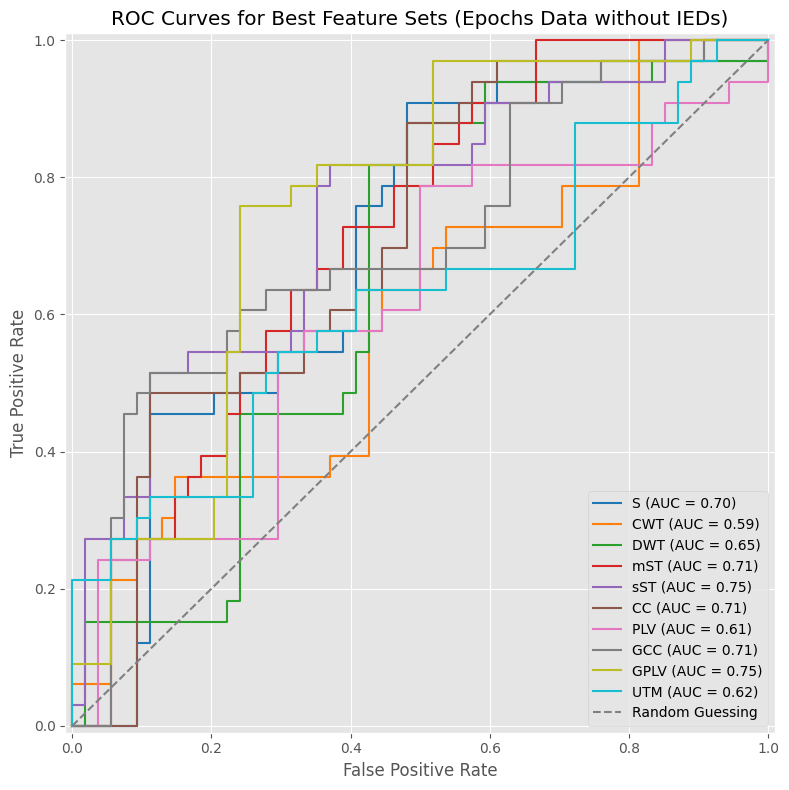

In [11]:
best_runs_epochs_without_ieds = {
    'spectral': ('CAR',5,'skew',('3910','807','773')),
    'cwt': ('CAR',10,'skew',('3005','4272','4906')),
    'dwt': ('Cz',10,'skew',('734','2369','548')),
    'mst': ('Laplacian',10,'mean',('2198','4830','2355')),
    'sst': ('Laplacian',1,'kurt',('3189','4663','4948')),
    'cc': ('Cz',10,'std',('4535','3261','2270')),
    'plv': ('Laplacian',10,'std',('1693','2417','3123')),
    'gcc': ('BipolarDB',1,'kurt',('3062','1524','1132')),
    'gplv': ('CAR',1,'std',('646','4833','1148')),
    'utm': ('Laplacian',2,'std',('838','3453','2031'))
}

# plot the ROC curves for the epochs data without IEDs
plt.figure(figsize=(8,8))
for feature_type in feat_types:
    montage, length, combiner, seeds = best_runs_epochs_without_ieds[feature_type]
    predictions_files = get_predictions_files(DATADIR_NOIED, montage, feature_type, length, combiner, seeds, epochs=True)

    roc_data = []
    preds=pd.DataFrame(columns=['y_tests','y_scores'])
    for file in predictions_files:
        df = pd.read_csv(os.path.join(DATADIR_NOIED, file))
        y_true = df['y_true'].values
        y_pred = df['y_prob'].values

        fpr, tpr, thresholds = metrics.roc_curve(y_true, y_pred)
        roc_data.append((fpr, tpr, thresholds))
        preds = pd.concat([preds, df[['y_true', 'y_prob']]],axis=0, ignore_index=True)
    fpr, tpr = vertical_avg_roc(roc_data)
    # pooled ROC curve
    y_true = np.array(preds['y_true'].values).astype(np.float64)
    y_pred = np.array(preds['y_prob'].values).astype(np.float64)
    fpr_pooled, tpr_pooled, _ = metrics.roc_curve(y_true=y_true, y_score=y_pred)
    auc_pooled = metrics.auc(fpr_pooled, tpr_pooled)
    plt.step(fpr_pooled, tpr_pooled, label=f'{featnames[feature_type]} (AUC = {auc_pooled:.2f})', color=colors[feat_types.index(feature_type)], linestyle='solid')
    print(f'{feature_type} Pooled AUC: {auc_pooled:.2f}')
plt.title('ROC Curves for Best Feature Sets (Epochs Data without IEDs)')
plt.plot([0, 1], [0, 1], '--', label='Random Guessing', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.xlim([-0.01, 1.01])
plt.ylim([-0.01, 1.01])
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()


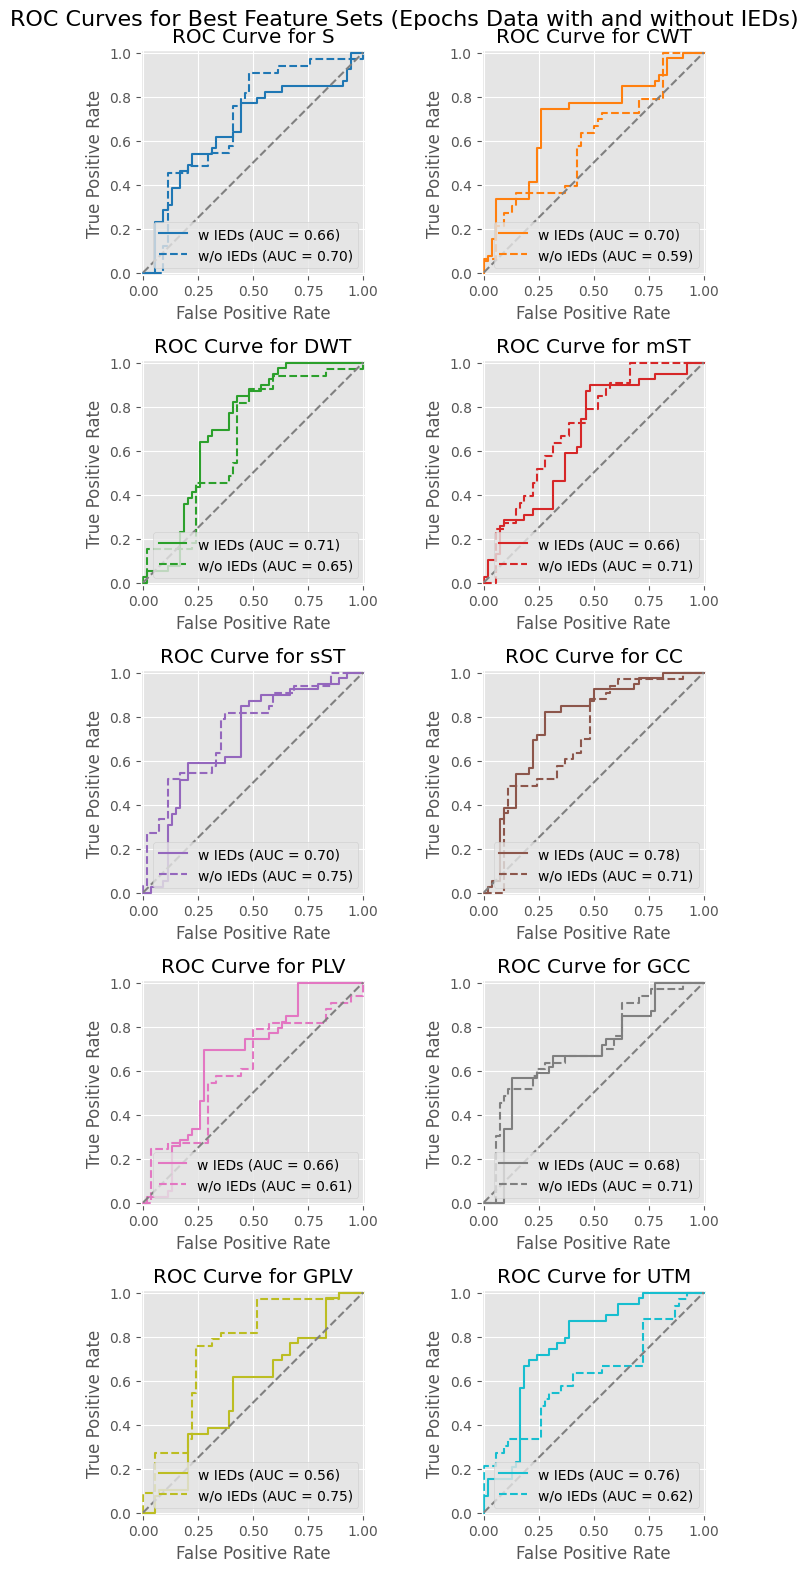

In [12]:
# 5x2 subplots with the ROC curves for each feature type comparing the epochs data with and without IEDs
fig, axs = plt.subplots(5, 2, figsize=(7, 16))
axs = axs.flatten()
for i, feature_type in enumerate(feat_types):
    montage, length, combiner, seeds = best_runs_epochs_with_ieds[feature_type]
    predictions_files = get_predictions_files(DATADIR_W_IEDS, montage, feature_type, length, combiner, seeds, epochs=True)

    roc_data = []
    preds=pd.DataFrame(columns=['y_tests','y_scores'])
    for file in predictions_files:
        df = pd.read_csv(os.path.join(DATADIR_W_IEDS, file))
        y_true = df['y_true'].values
        y_pred = df['y_prob'].values

        fpr, tpr, thresholds = metrics.roc_curve(y_true, y_pred)
        roc_data.append((fpr, tpr, thresholds))
        preds = pd.concat([preds, df[['y_true', 'y_prob']]],axis=0, ignore_index=True)
    fpr_w_ied, tpr_w_ied = vertical_avg_roc(roc_data)
    # pooled ROC curve
    y_true = np.array(preds['y_true'].values).astype(np.float64)
    y_pred = np.array(preds['y_prob'].values).astype(np.float64)
    fpr_pooled_w_ied, tpr_pooled_w_ied, _ = metrics.roc_curve(y_true=y_true, y_score=y_pred)
    auc_pooled_w_ied = metrics.auc(fpr_pooled_w_ied, tpr_pooled_w_ied)

    montage_noied, length_noied, combiner_noied, seeds_noied = best_runs_epochs_without_ieds[feature_type]
    predictions_files_noied = get_predictions_files(DATADIR_NOIED, montage_noied, feature_type, length_noied, combiner_noied, seeds_noied, epochs=True)

    roc_data_noied = []
    preds_noied=pd.DataFrame(columns=['y_tests','y_scores'])
    for file in predictions_files_noied:
        df = pd.read_csv(os.path.join(DATADIR_NOIED, file))
        y_true_noied = df['y_true'].values
        y_pred_noied = df['y_prob'].values

        fpr_noied, tpr_noied, thresholds_noied = metrics.roc_curve(y_true_noied, y_pred_noied)
        roc_data_noied.append((fpr_noied, tpr_noied, thresholds_noied))
        preds_noied    = pd.concat([preds_noied, df[['y_true', 'y_prob']]],axis=0, ignore_index=True)
    fpr_noied, tpr_noied = vertical_avg_roc(roc_data_noied)
    # pooled ROC curve
    y_true_noied = np.array(preds_noied['y_true'].values).astype(np.float64)
    y_pred_noied = np.array(preds_noied['y_prob'].values).astype(np.float64)
    fpr_pooled_noied, tpr_pooled_noied, _ = metrics.roc_curve(y_true=y_true_noied, y_score=y_pred_noied)
    auc_pooled_noied = metrics.auc(fpr_pooled_noied, tpr_pooled_noied)      
    axs[i].plot(fpr_pooled_w_ied, tpr_pooled_w_ied, label=f'w IEDs (AUC = {auc_pooled_w_ied:.2f})', color=colors[i], linestyle='solid')
    axs[i].plot(fpr_pooled_noied, tpr_pooled_noied, label=f'w/o IEDs (AUC = {auc_pooled_noied:.2f})', color=colors[i], linestyle='dashed')
    axs[i].set_title(f'ROC Curve for {featnames[feature_type]}')
    axs[i].plot([0, 1], [0, 1], '--', label='', color='gray')
    axs[i].set_xlabel('False Positive Rate')
    axs[i].set_ylabel('True Positive Rate')
    axs[i].set_xlim([-0.01, 1.01])
    axs[i].set_ylim([-0.01, 1.01])
    axs[i].legend(loc='lower right')
    axs[i].grid(True)      
    axs[i].set_aspect('equal')
plt.suptitle('ROC Curves for Best Feature Sets (Epochs Data with and without IEDs)', fontsize=16)
plt.tight_layout()
plt.show()
